In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix,
)

import warnings
warnings.filterwarnings("ignore")

print("All lib imported")

All lib imported


In [38]:
data=pd.read_csv("dataset/SMSSpamCollection",sep="\t",header=None,names=["label","message"])
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
print("Number of Rows:",data.shape[0])
print("Number of Columns:",data.shape[1])

Number of Rows: 5572
Number of Columns: 2


In [40]:
data.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [41]:
data.isnull().sum()

label      0
message    0
dtype: int64

In [42]:
print("Duplicate rows:",data.duplicated().sum())

Duplicate rows: 403


In [43]:
data["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

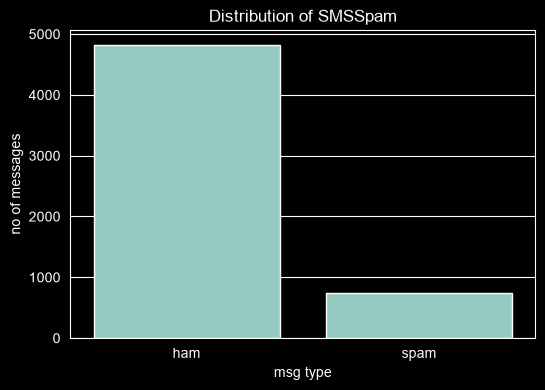

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=data,x="label")

plt.title("Distribution of SMSSpam")
plt.xlabel("msg type")
plt.ylabel("no of messages")

plt.show()

In [45]:
print("Duplicate rows : ",data.duplicated().sum())


Duplicate rows :  403


In [46]:
data=data.drop_duplicates()
print("dataset after dropping duplicate rows : ",data.shape)

dataset after dropping duplicate rows :  (5169, 2)


In [47]:
print("Duplicated rows:",data.duplicated().sum())

Duplicated rows: 0


In [48]:
data["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

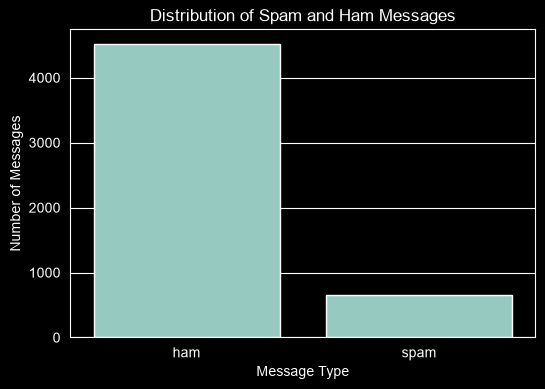

In [49]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [50]:
data["label"]=data["label"].map({"ham":0,"spam":1})
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [51]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [52]:
sample_message = "Congratulations!!! You've WON £1000!!! Visit http://example.com"

print("Original:")
print(sample_message)

print("\nCleaned:")
print(clean_text(sample_message))

Original:
Congratulations!!! You've WON £1000!!! Visit http://example.com

Cleaned:
congratulations youve won visit


In [53]:
data["clean_message"]=data["message"].apply(clean_text)

In [54]:
data[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [55]:
empty_message=data["clean_message"].str.strip().eq("").sum()
print("Empty message:",empty_message)

Empty message: 3


In [56]:
data = data[data["clean_message"].str.strip() != ""]

In [57]:
empty_message = data["clean_message"].str.strip().eq("").sum()
print("Empty message:", empty_message)

Empty message: 0


In [58]:
x=data["clean_message"]
y=data["label"]
print("number of msg:",len(x))
print("number of label:",len(y))

number of msg: 5166
number of label: 5166


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [61]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4132
Testing samples: 1034


In [63]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

In [64]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF transformation completed!")

TF-IDF transformation completed!


In [69]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4132, 29945)
Testing TF-IDF shape: (1034, 29945)


In [70]:
feature_names = vectorizer.get_feature_names_out()

print("Total number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Total number of features: 29945

First 50 features:
['aah' 'aah bless' 'aah cuddle' 'aah speak' 'aaniye' 'aaniye pudunga'
 'aaooooright' 'aaooooright work' 'aathilove' 'aathilove lot' 'ab'
 'ab sara' 'abbey' 'abbey happy' 'abeg' 'abeg make' 'abelu'
 'abelu havhear' 'aberdeen' 'aberdeen united' 'abi' 'abi hwkeep'
 'abi just' 'ability' 'ability listen' 'ability question' 'abiola' 'abj'
 'abj serving' 'able' 'able atten' 'able buy' 'able come' 'able deliver'
 'able dont' 'able eat' 'able half' 'able ill' 'able join' 'able late'
 'able little' 'able met' 'able morning' 'able ors' 'able pay'
 'able raise' 'able shopping' 'able value' 'abnormally' 'abnormally ill']


In [71]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [75]:
nb_predictions = nb_model.predict(X_test_tfidf)

print("First 20 predictions:")
print(nb_predictions[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [76]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 95.36%


In [77]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       1.00      0.63      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.87      1034
weighted avg       0.96      0.95      0.95      1034



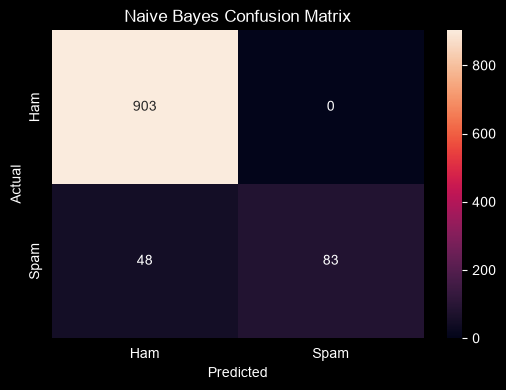

In [78]:
cm = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [79]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_predictions = lr_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 93.81%


In [80]:
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.93      1.00      0.97       903
        Spam       0.99      0.52      0.68       131

    accuracy                           0.94      1034
   macro avg       0.96      0.76      0.82      1034
weighted avg       0.94      0.94      0.93      1034



In [81]:
svm_model = LinearSVC()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(f"Linear SVM Accuracy: {svm_accuracy * 100:.2f}%")


Linear SVM Accuracy: 98.36%


In [82]:
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [83]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.drop(
    columns=["Accuracy"]
)

results

,Model,Accuracy (%)
0,Multinomial Naive Bayes,95.357834
1,Logistic Regression,93.810445
2,Linear SVM,98.355899


In [84]:
model_predictions = {
    "Naive Bayes": nb_predictions,
    "Logistic Regression": lr_predictions,
    "Linear SVM": svm_predictions
}

comparison = []

for model_name, predictions in model_predictions.items():

    comparison.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        )
    })

comparison_df = pd.DataFrame(comparison)

comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] *= 100

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,95.357834,100.000000,63.358779,77.570093
1,Logistic Regression,93.810445,98.550725,51.908397,68.000000
2,Linear SVM,98.355899,97.500000,89.312977,93.227092


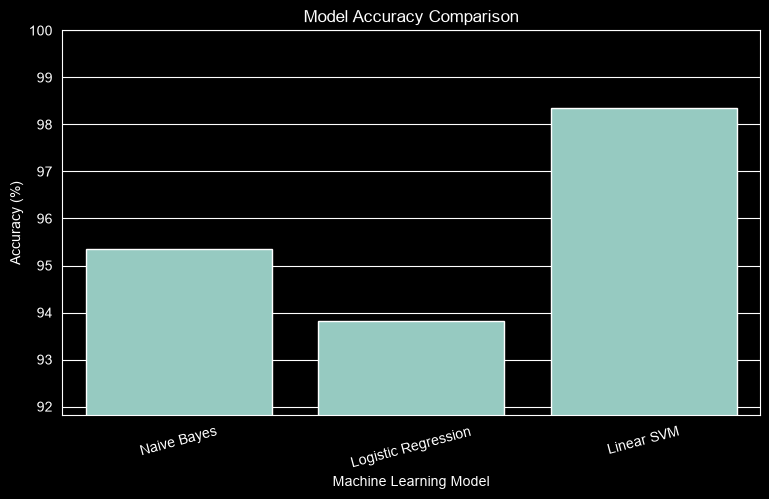

In [85]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.ylim(
    comparison_df["Accuracy"].min() - 2,
    100
)

plt.xticks(rotation=15)

plt.show()

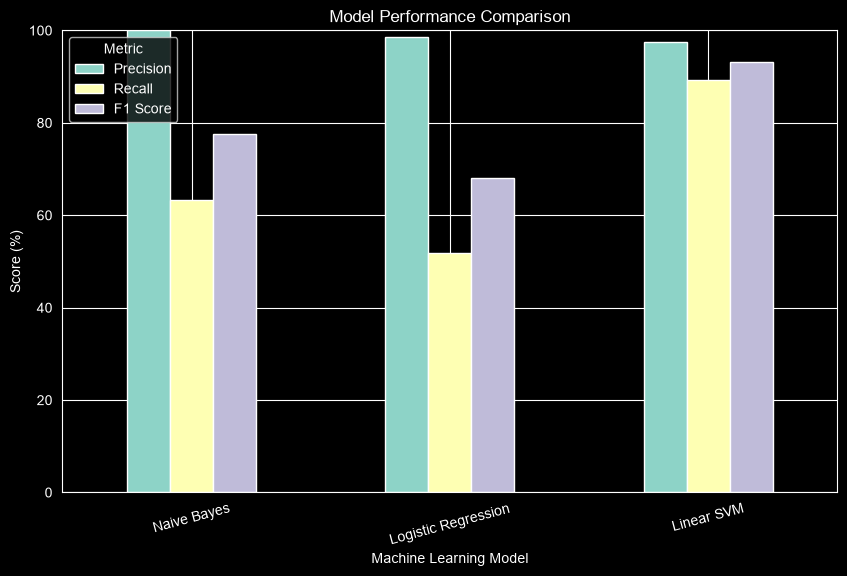

In [86]:
metrics_df = comparison_df.set_index("Model")[
    ["Precision", "Recall", "F1 Score"]
]

metrics_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")

plt.ylim(0, 100)

plt.xticks(rotation=15)

plt.legend(
    title="Metric"
)

plt.show()

In [87]:
best_model_name = comparison_df.loc[
    comparison_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1 Score:")
print(best_model_name)

Best model based on F1 Score:
Linear SVM


In [88]:
trained_models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model
}

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Linear SVM


In [89]:
test_messages = [
    "Congratulations! You have won a free prize. Click here to claim it!",
    "Hey bro, are you coming to college tomorrow?",
    "URGENT! You have won 50000 rupees. Call now!",
    "Can you send me the assignment?",
    "FREE entry in a weekly competition! Text WIN to 12345"
]

clean_test_messages = [
    clean_text(message)
    for message in test_messages
]

test_vectors = vectorizer.transform(
    clean_test_messages
)

predictions = best_model.predict(
    test_vectors
)

for message, prediction in zip(
    test_messages,
    predictions
):

    result = "SPAM 🚨" if prediction == 1 else "NOT SPAM ✅"

    print("\nMessage:", message)
    print("Prediction:", result)


Message: Congratulations! You have won a free prize. Click here to claim it!
Prediction: SPAM 🚨

Message: Hey bro, are you coming to college tomorrow?
Prediction: NOT SPAM ✅

Message: URGENT! You have won 50000 rupees. Call now!
Prediction: SPAM 🚨

Message: Can you send me the assignment?
Prediction: NOT SPAM ✅

Message: FREE entry in a weekly competition! Text WIN to 12345
Prediction: SPAM 🚨


In [93]:
message = input("enter ur message")

cleaned_message = clean_text(message)

message_vector = vectorizer.transform(
    [cleaned_message]
)

prediction = best_model.predict(
    message_vector
)[0]

if prediction == 1:
    print("\n🚨 SPAM MESSAGE")
else:
    print("\n✅ NOT SPAM")


🚨 SPAM MESSAGE
